In [30]:
import numpy as np
import matplotlib.pyplot as plt

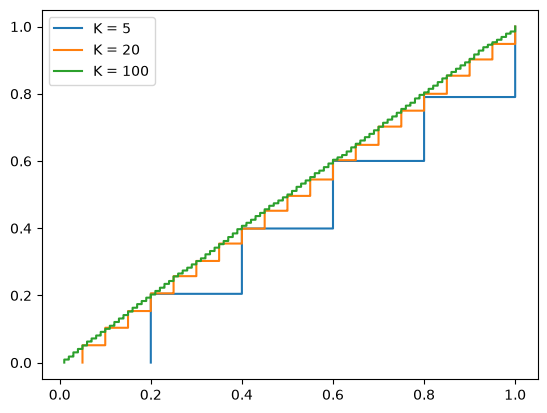

In [ ]:
# q1

rng = np.random.default_rng(0)
n = 5_000
def ecdf(draws):
    x = np.sort(draws)
    return x, np.arange(1, len(x) + 1) / len(x)

for K in [5, 20, 100]:
    grid = np.arange(1, K + 1) / K
    x, y = ecdf(rng.choice(grid, size=n))
    plt.step(x, y, where="post", label=f"K = {K}")

plt.legend()
plt.show()

As $K$ increases, the distribution converges to Uniform(0, 1), as the step size $\frac{1}{K}$ gets smaller and smaller, and the staircase approaches a straight line.

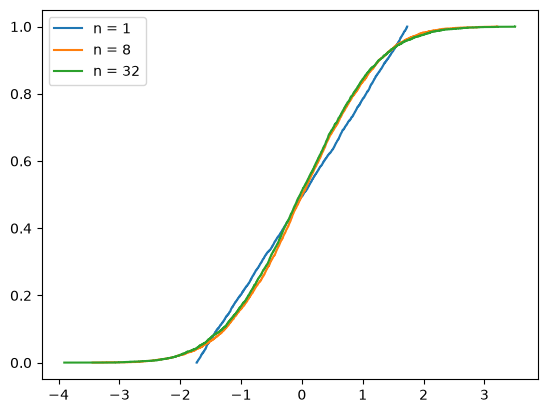

In [32]:
# q2
b = 5_000
for n in [1, 8, 32]:
    data = rng.uniform(-np.sqrt(3), np.sqrt(3), size=(b, n))
    scale = data.mean(axis=1) * np.sqrt(n)
    x, y = ecdf(scale)
    plt.step(x, y, where="post", label=f"n = {n}")

plt.legend()
plt.show()

As $n$ increases, it approaches the normal distribution Normal(0, 1). To get an average near the edge of the range, nearly all of the draws would need to be on the edge, which is unlikely. It is more probable that we get an average near the middle, since there are significantly more possible outcomes that would cancel out to a middle value, so the curve is steeper around the center.

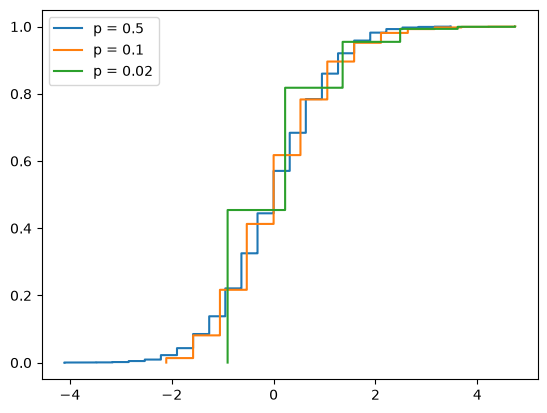

In [33]:
# q3
n = 40
b = 5_000
for p in [0.5, 0.1, 0.02]:
    heads = rng.binomial(n, p, size=b)
    scaled = (heads - n * p) / np.sqrt(n * p * (1 - p))
    x, y = ecdf(scaled)
    plt.step(x, y, where="post", label=f"p = {p}")

plt.legend()
plt.show()

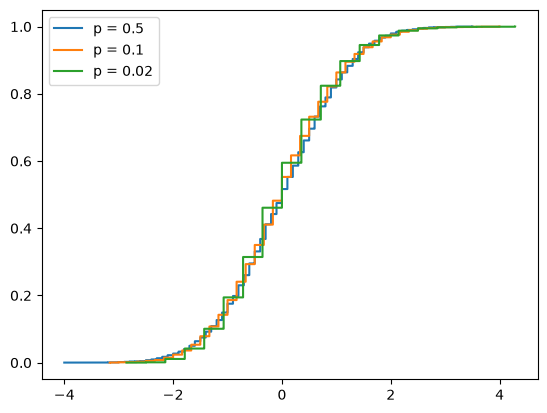

In [34]:
# q3
n = 400
b = 5_000
for p in [0.5, 0.1, 0.02]:
    heads = rng.binomial(n, p, size=b)
    scaled = (heads - n * p) / np.sqrt(n * p * (1 - p))
    x, y = ecdf(scaled)
    plt.step(x, y, where="post", label=f"p = {p}")

plt.legend()
plt.show()

**Q3**

5. As $n$ increases, it approaches Normal(0, 1). Like in Q2, the number of heads being near 0 or $n$ is highly unlikely since almost every flip needs to be the same. The counts in the middle have significantly more ways to happen, so they have higher probabilities to occur, and the curve is steeper there. The step sizes decrease as $n$ gets larger, so the curve approaches a smooth line.

6. As $p$ decreases towards 0, the expected number of heads drops and the distribution is squeezed at 0, since we cannot flip fewer heads than 0. At $p = 0.02$, we expect less than one head for $n= 40$, so the floor is right next to the center and the green line starts at around x=-1. The plot's large steps show around 45% of the runs having zero heads, 35% having one head, and the rest trails off on smaller step sizes. This makes the distribution skewed. The normal curve still appears for large enough $n$, once there is enough room on the left.

In [35]:
# q4
n = 5_000
def simulate(r, dt):
    time = np.zeros(n)
    alive = np.ones(n, dtype=bool)
    while alive.any():
        time[alive] += dt
        alive[alive] = rng.random(alive.sum()) >= r * dt
    return time

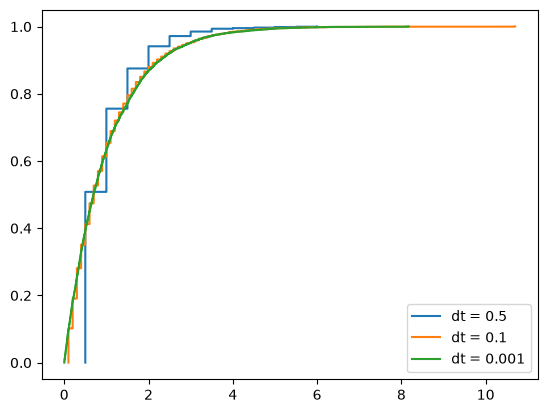

In [36]:
# q4.4
for dt in [0.5, 0.1, 1e-3]:
    x, y = ecdf(simulate(r=1, dt=dt))
    plt.step(x, y, where="post", label=f"dt = {dt}")

plt.legend()
plt.show()

The distribution approaches an exponential distribution with rate $r$. To still be going at time $t$, the process has to have survived $\frac{t}{dt}$ points of time. Each point survives with probability $1-r \cdot dt$, so the chance of surviving to $t$ is: $(1-r \cdot dt)^{\frac{t}{dt}}$, which approaches $e^{-rt}$.

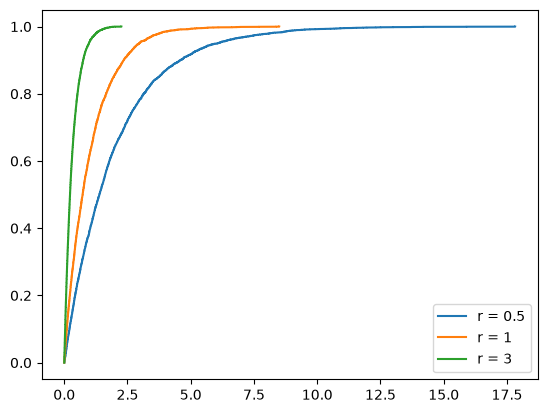

In [37]:
# q4.5
for r in [0.5, 1, 3]:
    x, y = ecdf(simulate(r=r, dt=1e-3))
    plt.step(x, y, where="post", label=f"r = {r}")

plt.legend()
plt.show()

$r$ is the rate at which the termination occurs, so as $r$ increases, the process ends sooner and the curve becomes steeper.